In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df=sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print("Размер таблицы (строк, колонок):", df.shape)
print()
print("Типы колонок:")
print(df.dtypes)

Размер таблицы (строк, колонок): (891, 15)

Типы колонок:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [5]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [6]:
# Колонки, которые дублируют другие или являются утечкой
columns_to_drop = ["alive", "class", "embark_town", "who", "adult_male"]

# Пока не удаляем — просто смотрим, что останется
df_clean = df.drop(columns=columns_to_drop)
print("Было колонок:", df.shape[1])
print("Стало колонок:", df_clean.shape[1])
print()
print("Оставшиеся колонки:")
for col in df_clean.columns:
    print(f"  - {col}")

Было колонок: 15
Стало колонок: 10

Оставшиеся колонки:
  - survived
  - pclass
  - sex
  - age
  - sibsp
  - parch
  - fare
  - embarked
  - deck
  - alone


In [7]:
missing = df_clean.isna().sum().sort_values(ascending=False)
missing_pct = (df_clean.isna().sum() / len(df_clean) * 100).round(1)

missing_df = pd.DataFrame({
    "пропущено": missing,
    "процент": missing_pct,
}).sort_values("процент", ascending=False)

print(missing_df[missing_df["пропущено"] > 0])

          пропущено  процент
deck            688     77.2
age             177     19.9
embarked          2      0.2


In [8]:
df_clean["age_missing"] = df_clean["age"].isna()

print("Выживаемость по группам:")
print(df_clean.groupby("age_missing")["survived"].agg(["count", "mean"]).round(3))

Выживаемость по группам:
             count   mean
age_missing              
False          714  0.406
True           177  0.294


In [9]:
df_clean = df_clean.drop(columns=["age_missing"])

In [10]:
df_clean["age"] = df_clean.groupby(["sex", "pclass"])["age"].transform(
    lambda x: x.fillna(x.median())
)

In [11]:
df_clean = df_clean.drop(columns=["deck"])
print("Колонок осталось:", df_clean.shape[1])

Колонок осталось: 9


In [12]:
df_clean = df_clean.dropna(subset=["embarked"])
print("Строк осталось:", df_clean.shape[0])

Строк осталось: 889


In [13]:
df_clean["age"] = df_clean.groupby(["sex", "pclass"])["age"].transform(
    lambda x: x.fillna(x.median())
)

In [14]:
print("Пропусков после обработки:")
print(df_clean.isna().sum())

Пропусков после обработки:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


In [15]:
df_clean.describe().round(2)

,survived,pclass,age,sibsp,parch,fare
count,889.00,889.00,889.00,889.00,889.00,889.00
mean,0.38,2.31,29.07,0.52,0.38,32.10
std,0.49,0.83,13.27,1.10,0.81,49.70
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,21.50,0.00,0.00,7.90
50%,0.00,3.00,26.00,0.00,0.00,14.45
75%,1.00,3.00,36.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


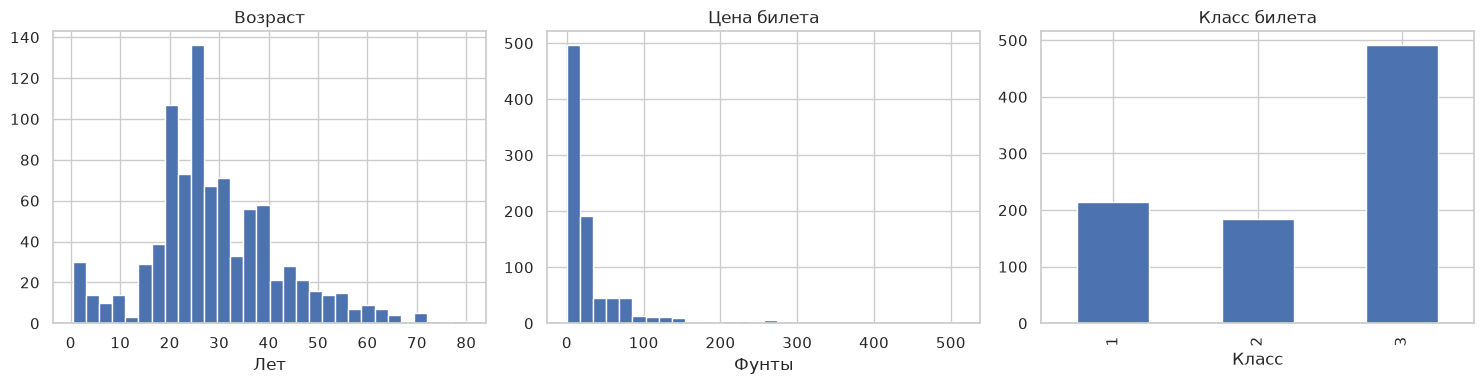

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_clean["age"].hist(bins=30, ax=axes[0])
axes[0].set_title("Возраст")
axes[0].set_xlabel("Лет")

df_clean["fare"].hist(bins=30, ax=axes[1])
axes[1].set_title("Цена билета")
axes[1].set_xlabel("Фунты")

df_clean["pclass"].value_counts().sort_index().plot(kind="bar", ax=axes[2])
axes[2].set_title("Класс билета")
axes[2].set_xlabel("Класс")

plt.tight_layout()
plt.show()

<Axes: >

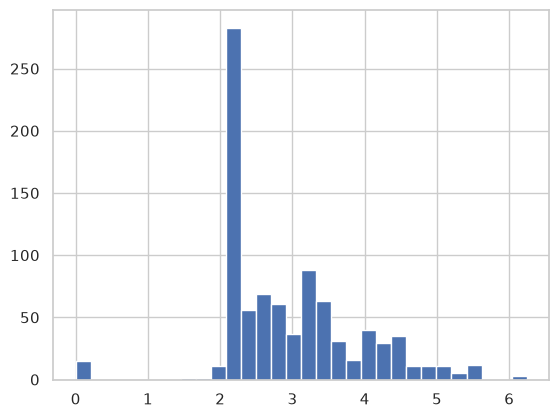

In [17]:
df_clean["fare_log"] = np.log1p(df_clean["fare"])
df_clean["fare_log"].hist(bins=30)

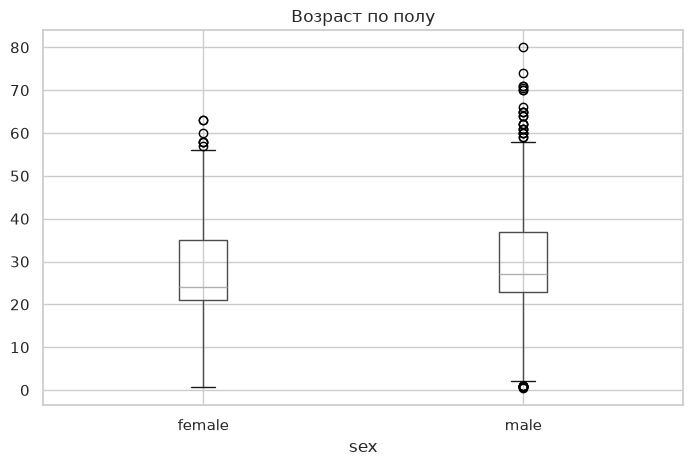

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
df_clean.boxplot(column="age", by="sex", ax=ax)
plt.title("Возраст по полу")
plt.suptitle("")  # убираем лишний заголовок
plt.show()

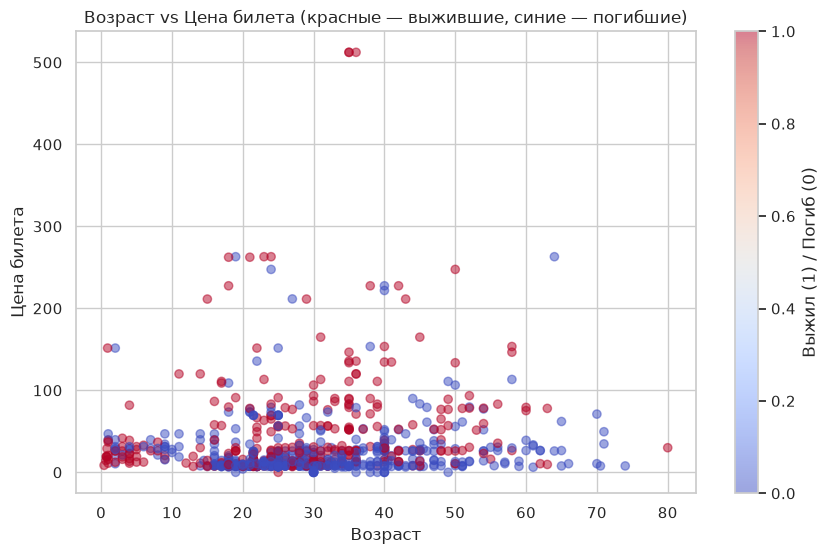

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean["age"], df_clean["fare"], alpha=0.5, c=df_clean["survived"], cmap="coolwarm")
plt.xlabel("Возраст")
plt.ylabel("Цена билета")
plt.title("Возраст vs Цена билета (красные — выжившие, синие — погибшие)")
plt.colorbar(label="Выжил (1) / Погиб (0)")
plt.show()

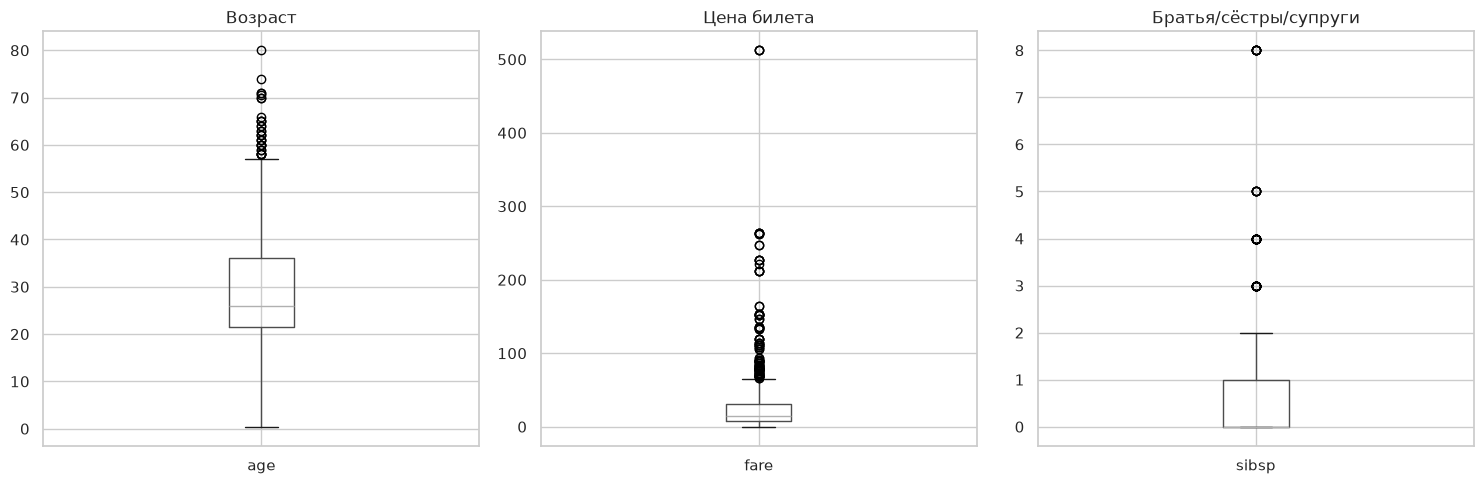

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df_clean.boxplot(column="age", ax=axes[0])
axes[0].set_title("Возраст")

df_clean.boxplot(column="fare", ax=axes[1])
axes[1].set_title("Цена билета")

df_clean.boxplot(column="sibsp", ax=axes[2])
axes[2].set_title("Братья/сёстры/супруги")

plt.tight_layout()
plt.show()

In [21]:
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < low) | (series > high)).sum()

for col in ["age", "fare", "sibsp", "parch"]:
    n = count_outliers(df_clean[col])
    print(f"{col}: {n} выбросов ({n / len(df_clean) * 100:.1f}%)")

age: 32 выбросов (3.6%)
fare: 114 выбросов (12.8%)
sibsp: 46 выбросов (5.2%)
parch: 213 выбросов (24.0%)


In [22]:
numeric_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df_clean[numeric_cols].corr().round(2)
corr

,survived,pclass,age,sibsp,parch,fare
survived,1.00,-0.34,-0.06,-0.03,0.08,0.26
pclass,-0.34,1.00,-0.41,0.08,0.02,-0.55
age,-0.06,-0.41,1.00,-0.25,-0.17,0.12
sibsp,-0.03,0.08,-0.25,1.00,0.41,0.16
parch,0.08,0.02,-0.17,0.41,1.00,0.22
fare,0.26,-0.55,0.12,0.16,0.22,1.00


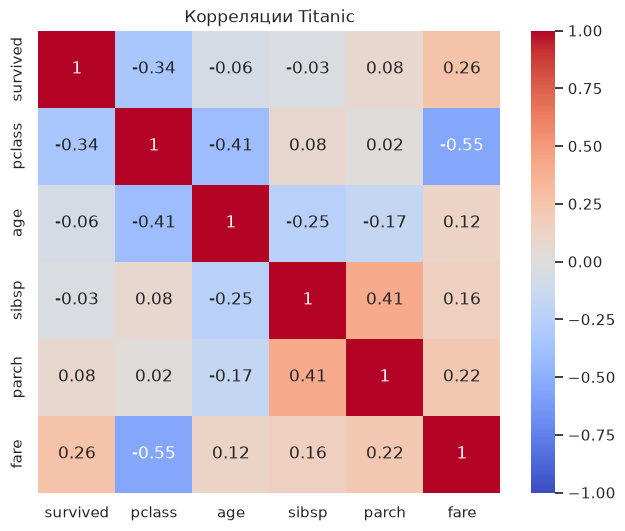

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Корреляции Titanic")
plt.show()

In [24]:
print("Выживаемость по полу:")
print(df_clean.groupby("sex")["survived"].agg(["count", "mean"]).round(3))

Выживаемость по полу:
        count   mean
sex                 
female    312  0.740
male      577  0.189


In [25]:
print("Выживаемость по классу:")
print(df_clean.groupby("pclass")["survived"].agg(["count", "mean"]).round(3))

Выживаемость по классу:
        count   mean
pclass              
1         214  0.626
2         184  0.473
3         491  0.242


In [26]:
print("Выживаемость по полу и классу:")
pivot = df_clean.groupby(["sex", "pclass"])["survived"].mean().round(3).unstack()
print(pivot)

Выживаемость по полу и классу:
pclass      1      2      3
sex                        
female  0.967  0.921  0.500
male    0.369  0.157  0.135


In [27]:
print("Выживаемость по порту посадки:")
print(df_clean.groupby("embarked")["survived"].agg(["count", "mean"]).round(3))

Выживаемость по порту посадки:
          count   mean
embarked              
C           168  0.554
Q            77  0.390
S           644  0.337


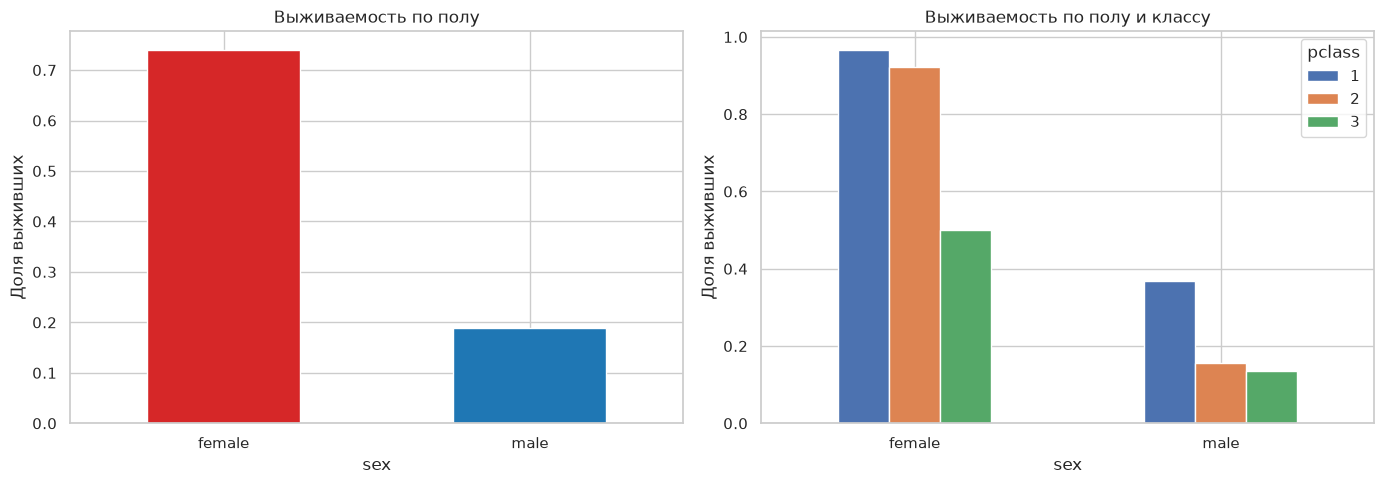

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean.groupby("sex")["survived"].mean().plot(kind="bar", ax=axes[0], color=["#d62728", "#1f77b4"])
axes[0].set_title("Выживаемость по полу")
axes[0].set_ylabel("Доля выживших")
axes[0].set_xticklabels(["female", "male"], rotation=0)

pivot.plot(kind="bar", ax=axes[1])
axes[1].set_title("Выживаемость по полу и классу")
axes[1].set_ylabel("Доля выживших")
axes[1].set_xticklabels(["female", "male"], rotation=0)

plt.tight_layout()
plt.show()

In [29]:
print("Дубликатов строк:", df_clean.duplicated().sum())

Дубликатов строк: 118


In [30]:
dups = df_clean[df_clean.duplicated(keep=False)]
print("Всего строк-дубликатов:", len(dups))
dups_sorted = dups.sort_values(list(df_clean.columns)).head(20)
dups_sorted

Всего строк-дубликатов: 175


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone,fare_log
263,0,1,male,40.0,0,0,0.0000,S,True,0.000000
633,0,1,male,40.0,0,0,0.0000,S,True,0.000000
815,0,1,male,40.0,0,0,0.0000,S,True,0.000000
30,0,1,male,40.0,0,0,27.7208,C,True,3.357622
64,0,1,male,40.0,0,0,27.7208,C,True,3.357622
295,0,1,male,40.0,0,0,27.7208,C,True,3.357622
252,0,1,male,62.0,0,0,26.5500,S,True,3.316003
555,0,1,male,62.0,0,0,26.5500,S,True,3.316003
144,0,2,male,18.0,0,0,11.5000,S,True,2.525729
757,0,2,male,18.0,0,0,11.5000,S,True,2.525729


In [31]:
print("Дубликатов в исходном df:", df.duplicated().sum())
print("Дубликатов в df_clean:", df_clean.duplicated().sum())

Дубликатов в исходном df: 107
Дубликатов в df_clean: 118


In [32]:
print("Баланс survived:")
print(df_clean["survived"].value_counts())
print()
print("Доли:")
print(df_clean["survived"].value_counts(normalize=True).round(3))

Баланс survived:
survived
0    549
1    340
Name: count, dtype: int64

Доли:
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


In [33]:
for col in ["sex", "embarked"]:
    print(f"\n=== {col} ===")
    print(df_clean[col].value_counts())


=== sex ===
sex
male      577
female    312
Name: count, dtype: int64

=== embarked ===
embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [34]:
for col in ["age", "fare", "sibsp", "parch"]:
    print(f"{col}: min = {df_clean[col].min()}, max = {df_clean[col].max()}")

age: min = 0.42, max = 80.0
fare: min = 0.0, max = 512.3292
sibsp: min = 0, max = 8
parch: min = 0, max = 6


In [35]:
print("Выживаемость по alone:")
print(df_clean.groupby("alone")["survived"].agg(["count", "mean"]).round(3))

Выживаемость по alone:
       count   mean
alone              
False    354  0.506
True     535  0.301


In [36]:
df_clean["is_child"] = df_clean["age"] < 10

print("Выживаемость детей vs взрослых:")
print(df_clean.groupby("is_child")["survived"].agg(["count", "mean"]).round(3))

Выживаемость детей vs взрослых:
          count   mean
is_child              
False       827  0.365
True         62  0.613


In [37]:
# Женщины, у которых были дети (parch > 0)
df_clean["is_mother"] = (df_clean["sex"] == "female") & (df_clean["parch"] > 0)

print("Выживаемость матерей vs остальных женщин:")
print(df_clean[df_clean["sex"] == "female"].groupby("is_mother")["survived"].agg(["count", "mean"]).round(3))

Выживаемость матерей vs остальных женщин:
           count   mean
is_mother              
False        192  0.786
True         120  0.667


In [38]:
df_clean["male_3rd"] = (df_clean["sex"] == "male") & (df_clean["pclass"] == 3)

print("Выживаемость мужчин 3-го класса vs остальных:")
print(df_clean.groupby("male_3rd")["survived"].agg(["count", "mean"]).round(3))

Выживаемость мужчин 3-го класса vs остальных:
          count   mean
male_3rd              
False       542  0.541
True        347  0.135


In [39]:
print("=== ИТОГОВЫЕ ГИПОТЕЗЫ (подтверждённые данными) ===")
print()
print("1. Женщины выживали чаще мужчин:")
print(f"   women: {df_clean[df_clean['sex']=='female']['survived'].mean():.1%}")
print(f"   men:   {df_clean[df_clean['sex']=='male']['survived'].mean():.1%}")
print()
print("2. 1-й класс выживал чаще 3-го:")
for pc in [1, 2, 3]:
    rate = df_clean[df_clean["pclass"] == pc]["survived"].mean()
    print(f"   класс {pc}: {rate:.1%}")
print()
print("3. Дети выживали чаще взрослых:")
print(f"   дети <10: {df_clean[df_clean['age']<10]['survived'].mean():.1%}")
print(f"   взрослые: {df_clean[df_clean['age']>=10]['survived'].mean():.1%}")
print()
print("4. Пассажиры с семьёй выживали чаще одиночек:")
print(f"   с семьёй: {df_clean[df_clean['alone']==False]['survived'].mean():.1%}")
print(f"   один:     {df_clean[df_clean['alone']==True]['survived'].mean():.1%}")
print()
print("5. Мужчины 3-го класса — самая обездоленная группа:")
print(f"   муж 3кл:   {df_clean[(df_clean['sex']=='male')&(df_clean['pclass']==3)]['survived'].mean():.1%}")
print(f"   остальные: {df_clean[~((df_clean['sex']=='male')&(df_clean['pclass']==3))]['survived'].mean():.1%}")

=== ИТОГОВЫЕ ГИПОТЕЗЫ (подтверждённые данными) ===

1. Женщины выживали чаще мужчин:
   women: 74.0%
   men:   18.9%

2. 1-й класс выживал чаще 3-го:
   класс 1: 62.6%
   класс 2: 47.3%
   класс 3: 24.2%

3. Дети выживали чаще взрослых:
   дети <10: 61.3%
   взрослые: 36.5%

4. Пассажиры с семьёй выживали чаще одиночек:
   с семьёй: 50.6%
   один:     30.1%

5. Мужчины 3-го класса — самая обездоленная группа:
   муж 3кл:   13.5%
   остальные: 54.1%


In [40]:
# Сначала решим, какие колонки оставляем
print("Колонки df_clean:", df_clean.columns.tolist())

Колонки df_clean: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone', 'fare_log', 'is_child', 'is_mother', 'male_3rd']


In [41]:
# Убираем временные колонки, которые мы создали для гипотез
cols_to_drop = ["is_child", "is_mother", "male_3rd"]
df_model = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])

# Оставляем fare_log? Давай сравним — с ним и без него.
# Пока оставим, потом посмотрим.

print("Колонки для модели:", df_model.columns.tolist())

Колонки для модели: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone', 'fare_log']


In [42]:
# sex: male/female → 0/1
df_model["sex"] = df_model["sex"].map({"male": 0, "female": 1})

# alone: True/False → 1/0
df_model["alone"] = df_model["alone"].astype(int)

# embarked: one-hot encoding
df_model = pd.get_dummies(df_model, columns=["embarked"], prefix="emb", drop_first=True)

print("Колонки после преобразования:")
print(df_model.columns.tolist())
print()
print(df_model.head())

Колонки после преобразования:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'fare_log', 'emb_Q', 'emb_S']

   survived  pclass  sex   age  sibsp  parch     fare  alone  fare_log  emb_Q  \
0         0       3    0  22.0      1      0   7.2500      0  2.110213  False   
1         1       1    1  38.0      1      0  71.2833      0  4.280593  False   
2         1       3    1  26.0      0      0   7.9250      1  2.188856  False   
3         1       1    1  35.0      1      0  53.1000      0  3.990834  False   
4         0       3    0  35.0      0      0   8.0500      1  2.202765  False   

   emb_S  
0   True  
1  False  
2   True  
3   True  
4   True  


In [43]:
y = df_model["survived"]
X = df_model.drop(columns=["survived"])

print("X:", X.shape)
print("y:", y.shape)
print()
print("Признаки:", X.columns.tolist())

X: (889, 10)
y: (889,)

Признаки: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'fare_log', 'emb_Q', 'emb_S']


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)
print()
print("Пропорция выживших в train:", y_train.mean().round(3))
print("Пропорция выживших в test: ", y_test.mean().round(3))

Train: (711, 10)
Test:  (178, 10)

Пропорция выживших в train: 0.383
Пропорция выживших в test:  0.382


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

In [46]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(f"Accuracy на train: {train_acc:.3f}")
print(f"Accuracy на test:  {test_acc:.3f}")
print(f"Baseline (всегда 'погиб'): {1 - y_test.mean():.3f}")

Accuracy на train: 0.809
Accuracy на test:  0.809
Baseline (всегда 'погиб'): 0.618


In [47]:
preds = model.predict(X_test)
cm = confusion_matrix(y_test, preds)

cm_df = pd.DataFrame(
    cm,
    index=["правда: погиб", "правда: выжил"],
    columns=["предсказано: погиб", "предсказано: выжил"],
)
print(cm_df)
print()
print(classification_report(y_test, preds, target_names=["погиб", "выжил"]))

               предсказано: погиб  предсказано: выжил
правда: погиб                  97                  13
правда: выжил                  21                  47

              precision    recall  f1-score   support

       погиб       0.82      0.88      0.85       110
       выжил       0.78      0.69      0.73        68

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.79       178
weighted avg       0.81      0.81      0.81       178



In [48]:
coefs = pd.DataFrame({
    "признак": X.columns,
    "вес": model.coef_[0],
}).sort_values("вес", key=abs, ascending=False)

print(coefs.round(3))

    признак    вес
1       sex  2.441
0    pclass -0.913
6     alone -0.478
3     sibsp -0.472
7  fare_log  0.429
8     emb_Q  0.347
4     parch -0.249
9     emb_S -0.207
2       age -0.040
5      fare -0.003


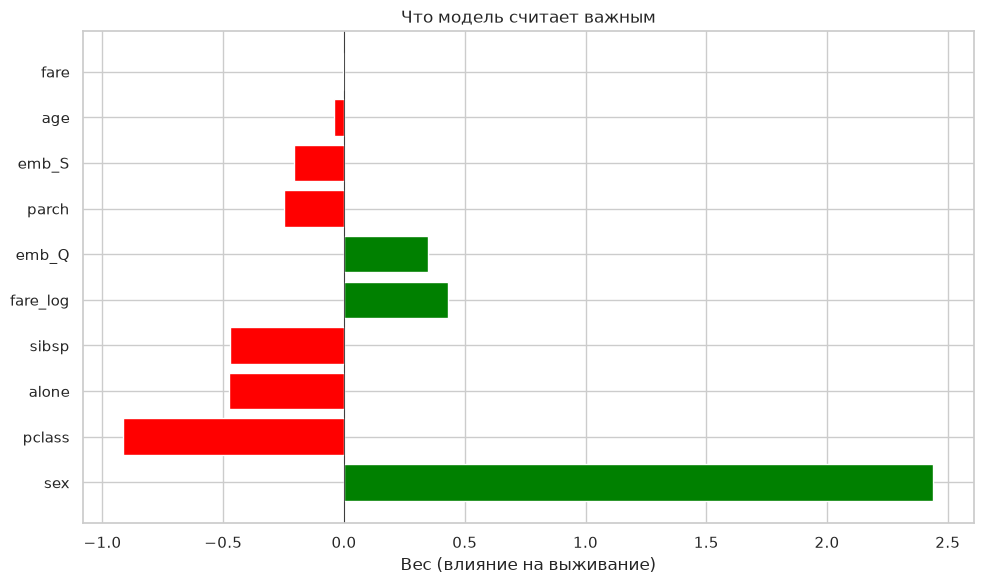

In [49]:
plt.figure(figsize=(10, 6))
colors = ["red" if c < 0 else "green" for c in coefs["вес"]]
plt.barh(coefs["признак"], coefs["вес"], color=colors)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("Вес (влияние на выживание)")
plt.title("Что модель считает важным")
plt.tight_layout()
plt.show()

In [50]:
# Модель БЕЗ fare_log
X_no_log = X.drop(columns=["fare_log"])
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_no_log, y, test_size=0.2, random_state=42, stratify=y
)
model_nl = LogisticRegression(max_iter=1000)
model_nl.fit(X_train_nl, y_train_nl)
print(f"Без fare_log: {model_nl.score(X_test_nl, y_test_nl):.3f}")

# Модель С fare_log (у нас уже есть)
print(f"С fare_log:   {model.score(X_test, y_test):.3f}")

Без fare_log: 0.809
С fare_log:   0.809


In [51]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

print(f"LogisticRegression: {model.score(X_test, y_test):.3f}")
print(f"DecisionTree:       {tree.score(X_test, y_test):.3f}")

LogisticRegression: 0.809
DecisionTree:       0.775


In [52]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

print(f"LogisticRegression: {model.score(X_test, y_test):.3f}")
print(f"DecisionTree:       {tree.score(X_test, y_test):.3f}")
print(f"RandomForest:       {rf.score(X_test, y_test):.3f}")

LogisticRegression: 0.809
DecisionTree:       0.775
RandomForest:       0.826


In [53]:
importances = pd.DataFrame({
    "признак": X.columns,
    "важность": rf.feature_importances_,
}).sort_values("важность", ascending=False)

print(importances.round(3))

    признак  важность
1       sex     0.399
7  fare_log     0.137
5      fare     0.124
2       age     0.114
0    pclass     0.110
3     sibsp     0.039
4     parch     0.022
9     emb_S     0.021
6     alone     0.019
8     emb_Q     0.014


In [54]:
# Убираем дубликат
X_clean = X.drop(columns=["fare_log"])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

rf_clean = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clean.fit(X_train_c, y_train_c)

print(f"RandomForest с fare_log:    {rf.score(X_test, y_test):.3f}")
print(f"RandomForest без fare_log:  {rf_clean.score(X_test_c, y_test_c):.3f}")

# Feature importance после чистки
importances = pd.DataFrame({
    "признак": X_clean.columns,
    "важность": rf_clean.feature_importances_,
}).sort_values("важность", ascending=False)
print()
print(importances.round(3))

RandomForest с fare_log:    0.826
RandomForest без fare_log:  0.831

  признак  важность
1     sex     0.459
5    fare     0.163
0  pclass     0.130
2     age     0.124
3   sibsp     0.040
4   parch     0.025
8   emb_S     0.023
6   alone     0.020
7   emb_Q     0.016


In [55]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_clean, X_clean, y, cv=5, scoring="accuracy")

print("Accuracy на 5 фолдах:", cv_scores.round(3))
print(f"Среднее: {cv_scores.mean():.3f}")
print(f"Стандартное отклонение: {cv_scores.std():.3f}")

Accuracy на 5 фолдах: [0.798 0.815 0.826 0.792 0.859]
Среднее: 0.818
Стандартное отклонение: 0.024


In [56]:
for depth in [3, 5, 7, 10, None]:
    rf = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    scores = cross_val_score(rf, X_clean, y, cv=5, scoring="accuracy")
    print(f"max_depth={str(depth):>4}: mean={scores.mean():.3f}, std={scores.std():.3f}")

max_depth=   3: mean=0.814, std=0.017
max_depth=   5: mean=0.818, std=0.024
max_depth=   7: mean=0.817, std=0.023
max_depth=  10: mean=0.825, std=0.033
max_depth=None: mean=0.817, std=0.040


In [57]:
probs = rf_clean.predict_proba(X_test_c)[:, 1]  # вероятность "выжил"

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (probs >= threshold).astype(int)
    acc = accuracy_score(y_test_c, preds)
    print(f"Порог {threshold}: accuracy = {acc:.3f}")

Порог 0.3: accuracy = 0.775
Порог 0.4: accuracy = 0.792
Порог 0.5: accuracy = 0.831
Порог 0.6: accuracy = 0.826
Порог 0.7: accuracy = 0.792
